# A2 — Graphene band structure & the Dirac cone

Companion notebook to Advanced chapter A2. We plot the graphene bands along
Γ–M–K–Γ (`code/advanced/02-dirac-bands/graphene.bands.dat.gnu`), aligned to
the Fermi level, and zoom in on the **Dirac point** at K. Requirements:
`numpy`, `matplotlib`.

In [1]:
import numpy as np
from pathlib import Path

d = Path('../code/advanced/02-dirac-bands')
EF = -4.2250   # Fermi level (eV) from graphene.scf.out

# bands.x .gnu: blank-line-separated blocks, one band each (q-distance, energy)
blocks, cur = [], []
for line in (d/'graphene.bands.dat.gnu').read_text().splitlines():
    if line.strip(): cur.append([float(x) for x in line.split()[:2]])
    elif cur: blocks.append(np.array(cur)); cur = []
if cur: blocks.append(np.array(cur))
kdist = blocks[0][:, 0]
bands = np.array([b[:, 1] for b in blocks]) - EF   # (nbnd, nk), shifted to EF
print(f'{bands.shape[0]} bands, {bands.shape[1]} k-points')

ticks, labels = [], []
for line in (d/'highsym.dat').read_text().splitlines():
    if line.strip() and not line.startswith('#'):
        x, lab = line.split(); ticks.append(float(x)); labels.append(lab)
iK = np.argmin(np.abs(kdist - 0.9107))
near = np.sort(np.abs(bands[:, iK]))[:2]
print(f'gap at K = {near.sum():.3f} eV  (Dirac point: ~0)')

12 bands, 161 k-points
gap at K = 0.038 eV  (Dirac point: ~0)


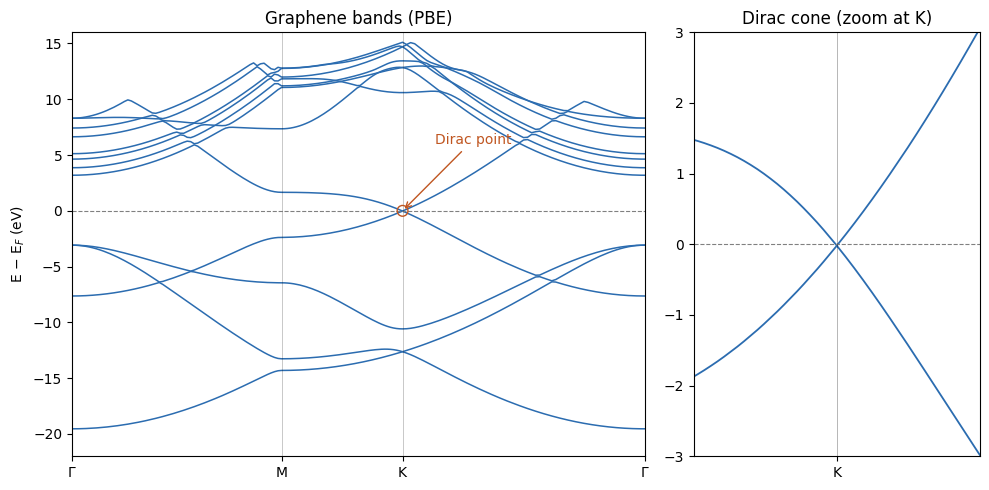

In [2]:
import matplotlib.pyplot as plt

fig, (axf, axz) = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios':[2,1]})
# full bands
for b in bands:
    axf.plot(kdist, b, color='#2b6cb0', lw=1.1)
axf.axhline(0, color='gray', ls='--', lw=0.8)
for x in ticks: axf.axvline(x, color='k', lw=0.5, alpha=0.3)
axf.set_xticks(ticks); axf.set_xticklabels(labels)
axf.set_xlim(kdist.min(), kdist.max()); axf.set_ylim(-22, 16)
axf.set_ylabel('E − E$_F$ (eV)'); axf.set_title('Graphene bands (PBE)')
axf.scatter([0.9107], [0], s=60, facecolors='none', edgecolors='#c05621', zorder=5)
axf.annotate('Dirac point', xy=(0.9107, 0), xytext=(1.0, 6),
             color='#c05621', arrowprops=dict(arrowstyle='->', color='#c05621'))
# zoom on the Dirac cone around K
for b in bands:
    axz.plot(kdist, b, color='#2b6cb0', lw=1.3)
axz.axhline(0, color='gray', ls='--', lw=0.8)
axz.axvline(0.9107, color='k', lw=0.5, alpha=0.4)
axz.set_xticks([0.9107]); axz.set_xticklabels(['K'])
axz.set_xlim(0.9107-0.18, 0.9107+0.18); axz.set_ylim(-3, 3)
axz.set_title('Dirac cone (zoom at K)')
fig.tight_layout()
fig.savefig(d.parent.parent.parent/'static/img/A2-dirac-bands.png', dpi=120)
plt.show()

**What you see.** The valence and conduction π bands meet at a single
point at **K**, exactly at the Fermi level — the **Dirac point**. Zoomed in
(right), the bands are **linear** in $\mathbf{k}$ around K (the Dirac
cone), so low-energy electrons behave like massless relativistic particles
— the hallmark of graphene. The deeper, parabolic bands near −8 to −20 eV
are the σ (sp²) bonding states. Graphene is a **semimetal**: zero gap, but
zero density of states *at* the point.